In [1]:
import decoupler as dc


import numpy as np
import pandas as pd
import sc_atlas_helpers as ah
import scanpy as sc


# from scanpy_helper_submodule import scanpy_helpers as sh

In [2]:
pd.__version__

'1.5.3'

In [3]:
import contextlib
import os

import numpy as np
import scipy.sparse
import statsmodels.stats.multitest
from anndata import AnnData
from tqdm.auto import tqdm

## Define paths

In [4]:
adata = sc.read_h5ad(
    "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/13_january_2025/mapped_data/mapped_til_colon.h5ad"
)

In [5]:
adata.var

,ensembl_id,feature_types,gene_name,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,n_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
ensembl_id,,,,,,,,,,,,,,,,,,,
ENSMUSG00000033845,ENSMUSG00000033845,Gene Expression,Mrpl15,False,False,15644,1.169332,0.774419,78.998805,87104.710938,11.374878,21484,24002.0,False,NaN,1.327405,5.528502,0.963611,0
ENSMUSG00000025903,ENSMUSG00000025903,Gene Expression,Lypla1,False,False,14215,1.073952,0.729456,80.917158,79999.789062,11.289792,19725,20230.0,False,NaN,1.222800,5.273152,0.967138,0
ENSMUSG00000033813,ENSMUSG00000033813,Gene Expression,Tcea1,False,False,30545,2.373390,1.215918,58.995046,176796.218750,12.082759,40436,45545.0,False,NaN,2.598504,8.122003,0.966765,0
ENSMUSG00000033793,ENSMUSG00000033793,Gene Expression,Atp6v1h,False,False,10560,0.817953,0.597711,85.823791,60930.109375,11.017499,14481,14530.0,False,3409.5,0.916394,4.352974,0.998627,2
ENSMUSG00000025907,ENSMUSG00000025907,Gene Expression,Rb1cc1,False,False,15940,1.282039,0.825069,78.601442,95500.367188,11.466896,21130,21450.0,False,2045.0,1.386223,6.238710,1.023630,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000063897,ENSMUSG00000063897,Gene Expression,CAAA01118383.1,False,False,7156,0.550870,0.438816,90.393470,41034.832031,10.622201,9764,9803.0,False,2894.0,0.614820,3.085952,0.994008,1
ENSMUSG00000051412,ENSMUSG00000051412,Gene Expression,Vamp7,False,False,4551,0.335245,0.289115,93.890537,24972.708984,10.125579,6640,6672.0,False,2992.0,0.401343,2.003972,0.963557,1
ENSMUSG00000079834,ENSMUSG00000079834,Gene Expression,Tmlhe,False,False,488,0.038844,0.038109,99.344887,2893.559814,7.970588,592,598.0,True,978.0,0.039054,0.227810,0.900718,9


In [6]:
adata = adata[~adata.obs["cell_type"].isin(["nan"])]

In [7]:
adata = adata[~adata.obs["condition"].isin(["GF","GF-plus"])]

In [8]:
adata

View of AnnData object with n_obs × n_vars = 37056 × 11945
    obs: '_scvi_batch', '_scvi_labels', 'batch', 'batch_id', 'cell_type', 'condition', 'is_doublet', 'is_outlier', 'is_outlier_counts', 'is_outlier_genes', 'is_outlier_mito', 'is_outlier_top_20', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'n_counts', 'n_genes', 'n_genes_by_counts', 'origin', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'sample_id', 'total_counts', 'total_counts_mt', 'total_counts_ribo', 'value', 'outlier', 'mt_outlier', 'ribo_outlier', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'functional.cluster'
    var: 'ensembl_id', 'feature_types', 'gene_name', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    

In [9]:
adata_normal = adata[adata.obs["origin"]=="colon"]

In [10]:
adata_tumor = adata[adata.obs["origin"]=="til"]

In [11]:
adata = adata

In [52]:
adata.var[adata.var["ensembl_id"] =="ENSMUSG00000026180"]

,ensembl_id,feature_types,gene_name,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,n_counts,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
ensembl_id,,,,,,,,,,,,,,,,,,,


/tmp/ipykernel_2809325/2538458438.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="condition", y=gene, data=df, palette="seismic")


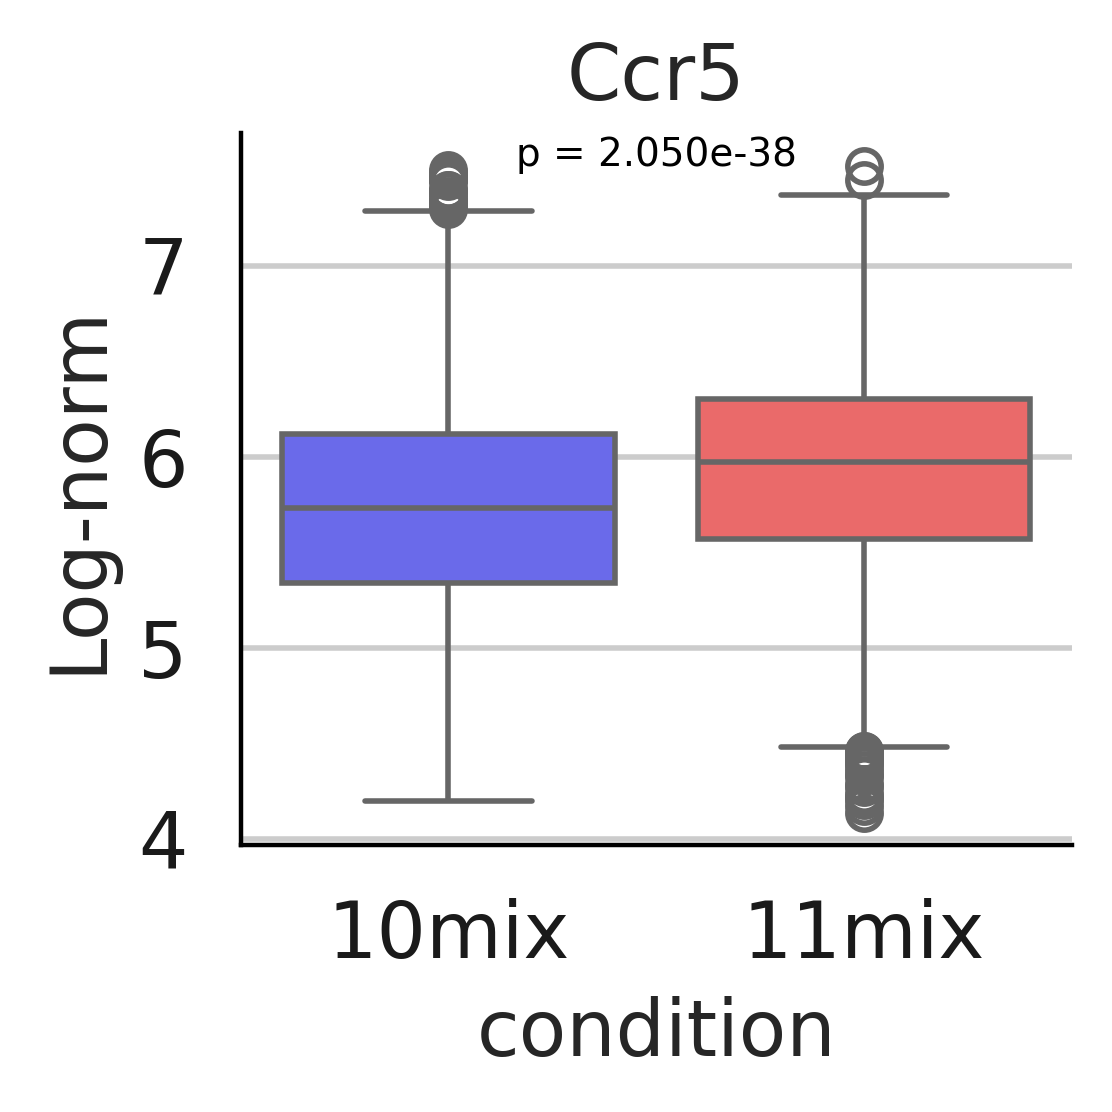

Mann-Whitney U test for Ccr5: U-statistic = 6102360.500, p-value = 2.050e-38


In [55]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Ensure the metadata contains a column with condition labels
condition_col = "condition"  # Adjust if necessary
cell_type_col = "cell_type"  # Adjust if necessary


#mouse_genes = ["Slc22a17", "Lrp2", "Cxcr2", "Ccr6", "Tnfrsf1a", "Tnfrsf1b", "Cxcr3", "Cxcr4", "Ccr2"]
gene_name= "Ccr5"

# Define **mouse** homologs of receptors
mouse_genes = [gene_name]  # Mouse gene symbols

# Map gene symbols to Ensembl IDs
gene_map = adata.var[adata.var["gene_name"].isin(mouse_genes)]
ensembl_ids = gene_map.index.tolist()  # Get corresponding Ensembl IDs

# Extract log-normalized expression values from "logcounts" layer
if "logcounts" in adata.layers:
    logcounts_data = adata[:, ensembl_ids].layers["logcounts"]
else:
    raise ValueError("Layer 'logcounts' not found in adata.")

# Convert expression data to a DataFrame
df = pd.DataFrame(logcounts_data, columns=gene_map["gene_name"].values, index=adata.obs.index)

# Add condition labels
df["condition"] = adata.obs[condition_col]

# Filter for 11mix and 10mix conditions
df = df[df["condition"].isin(["11mix", "10mix"])]


receptor_columns = [gene_name]

# Remove rows where there are more than 2 zeros in the receptor columns
df = df[(df[receptor_columns] != 0).sum(axis=1) > len(receptor_columns) - 1]

# Initialize figure
plt.figure(figsize=(3,3))

# Perform Mann-Whitney U test for statistical comparison
gene = gene_name
group_11mix = df[df["condition"] == "11mix"][gene]
group_10mix = df[df["condition"] == "10mix"][gene]
u_stat, p_value = mannwhitneyu(group_11mix, group_10mix, alternative="two-sided")

# Boxplot
sns.boxplot(x="condition", y=gene, data=df, palette="seismic")

# Remove the top and right spines (frame)
sns.despine()


# Annotate statistical significance
plt.text(0.5, df[gene].max(), f"p = {p_value:.3e}", ha="center", fontsize=7, color="black")

# Plot formatting
plt.title(f"{gene}")

plt.ylabel("Log-norm")

plt.tight_layout()
# Save the figure in multiple formats
plt.savefig(f"./figures/{gene_name}.svg", format="svg", dpi=300)
plt.savefig(f"./figures/{gene_name}.pdf", format="pdf", dpi=300)
plt.savefig(f"./figures/{gene_name}.png", format="png", dpi=300)

# Show the plot
plt.show()

plt.show()

# Print statistical result
print(f"Mann-Whitney U test for {gene}: U-statistic = {u_stat:.3f}, p-value = {p_value:.3e}")




/tmp/ipykernel_2809325/2988018690.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/2988018690.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/2988018690.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/2988018690.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

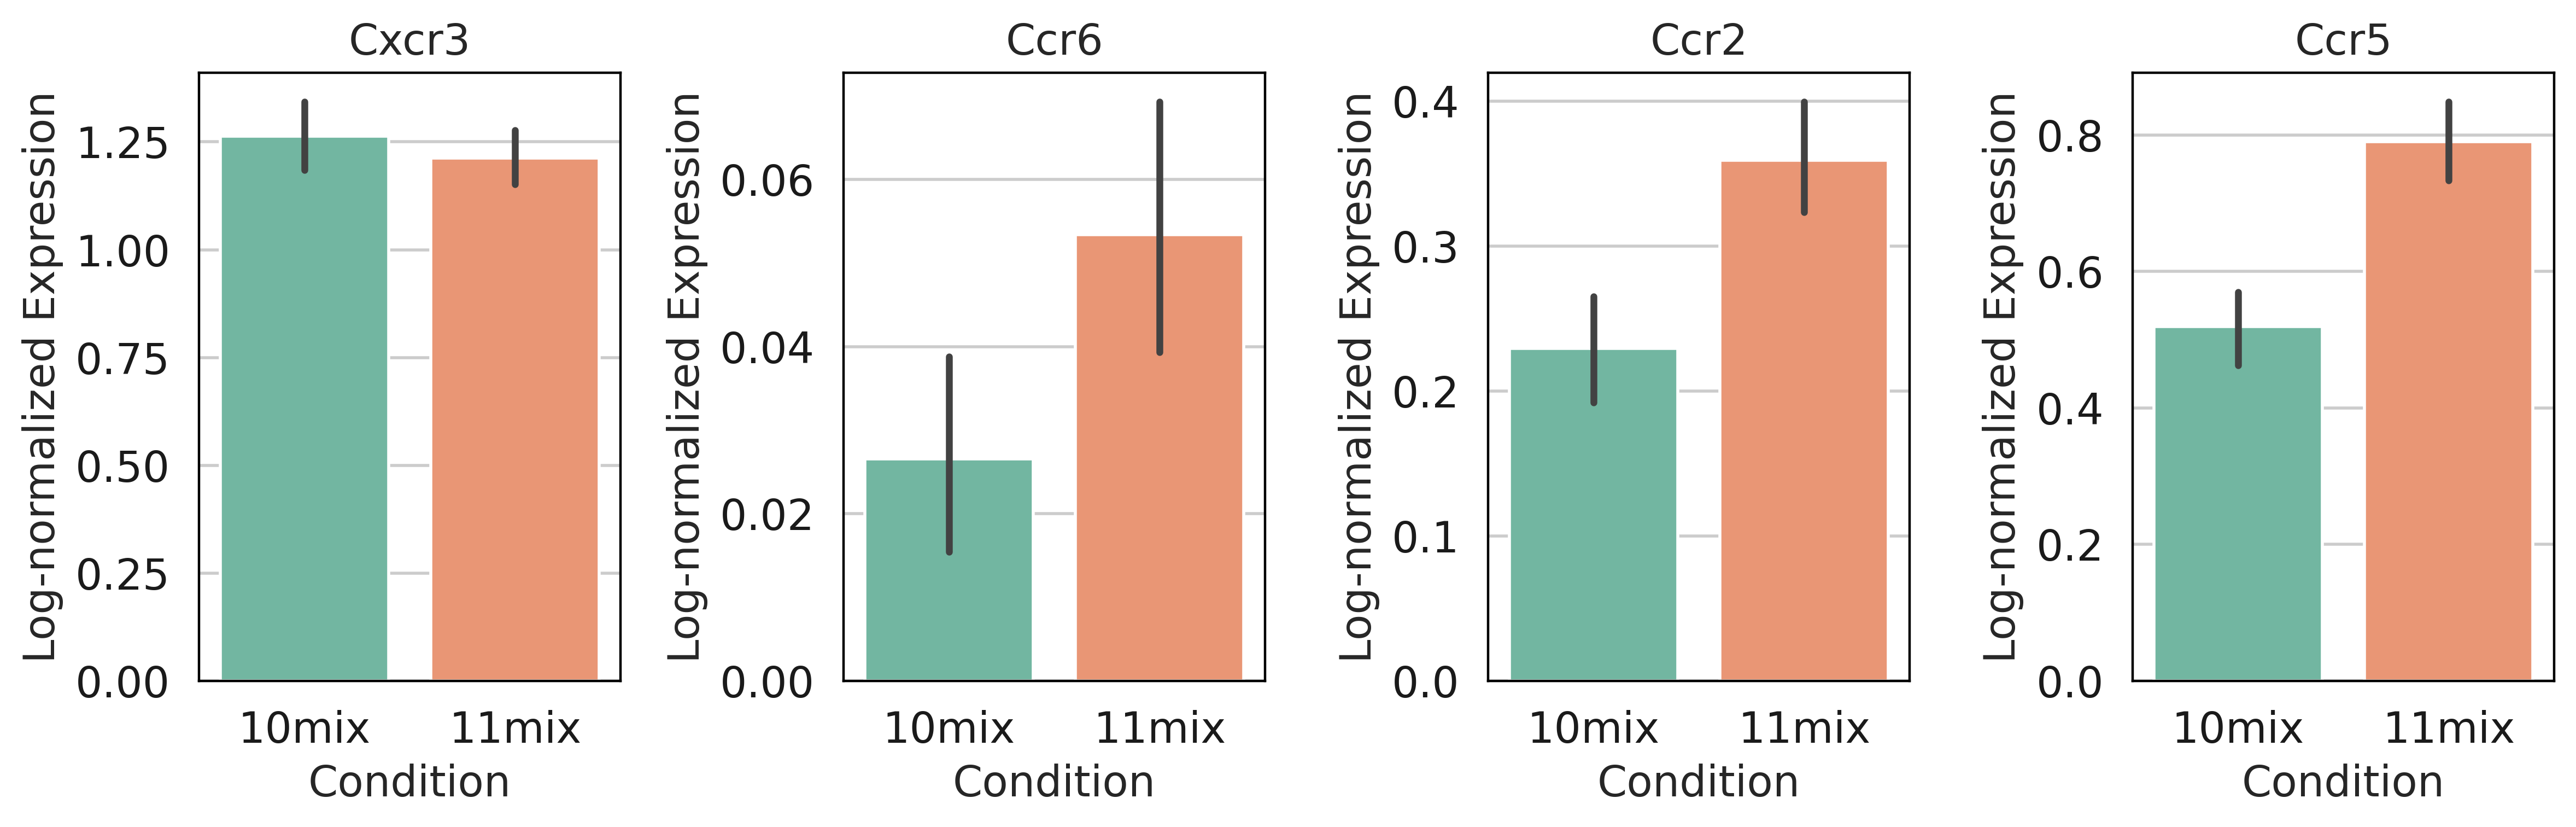

In [13]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Ensure the metadata contains a column with condition labels
condition_col = "condition"  # Adjust if necessary
cell_type_col = "cell_type"  # Adjust if necessary

# Define **mouse** homologs of receptors
mouse_genes = ["Cxcr3", "Ccr6","Ccr2","Ccr5"]  # Mouse gene symbols

# Map gene symbols to Ensembl IDs
gene_map = adata_normal.var[adata_normal.var["gene_name"].isin(mouse_genes)]
ensembl_ids = gene_map.index.tolist()  # Get corresponding Ensembl IDs

# Extract log-normalized expression values from "logcounts" layer
if "logcounts" in adata_normal.layers:
    logcounts_data = adata_normal[:, ensembl_ids].layers["logcounts"]
else:
    raise ValueError("Layer 'logcounts' not found in adata.")

# Convert expression data to a DataFrame
df = pd.DataFrame(logcounts_data, columns=gene_map["gene_name"].values, index=adata_normal.obs.index)

# Add condition labels
df["condition"] = adata_normal.obs[condition_col]

# Filter for 11mix and 10mix conditions
df = df[df["condition"].isin(["11mix", "10mix"])]

# Define the receptor gene columns (excluding 'condition')
receptor_columns = ["Cxcr3", "Ccr6", "Ccr2"]

# Remove rows where there are more than 2 zeros in the receptor columns
#df = df[(df[receptor_columns] != 0).sum(axis=1) > len(receptor_columns) - 1]

# Plot expression differences using violin plots
plt.figure(figsize=(12, 4))
for i, gene in enumerate(mouse_genes):
    plt.subplot(1, 4, i + 1)
    sns.barplot(x="condition", y=gene, data=df, palette="Set2")
    plt.title(f"{gene}")
    plt.xlabel("Condition")
    plt.ylabel("Log-normalized Expression")

plt.tight_layout()
plt.show()



/tmp/ipykernel_2809325/3607069111.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/3607069111.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/3607069111.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/3607069111.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

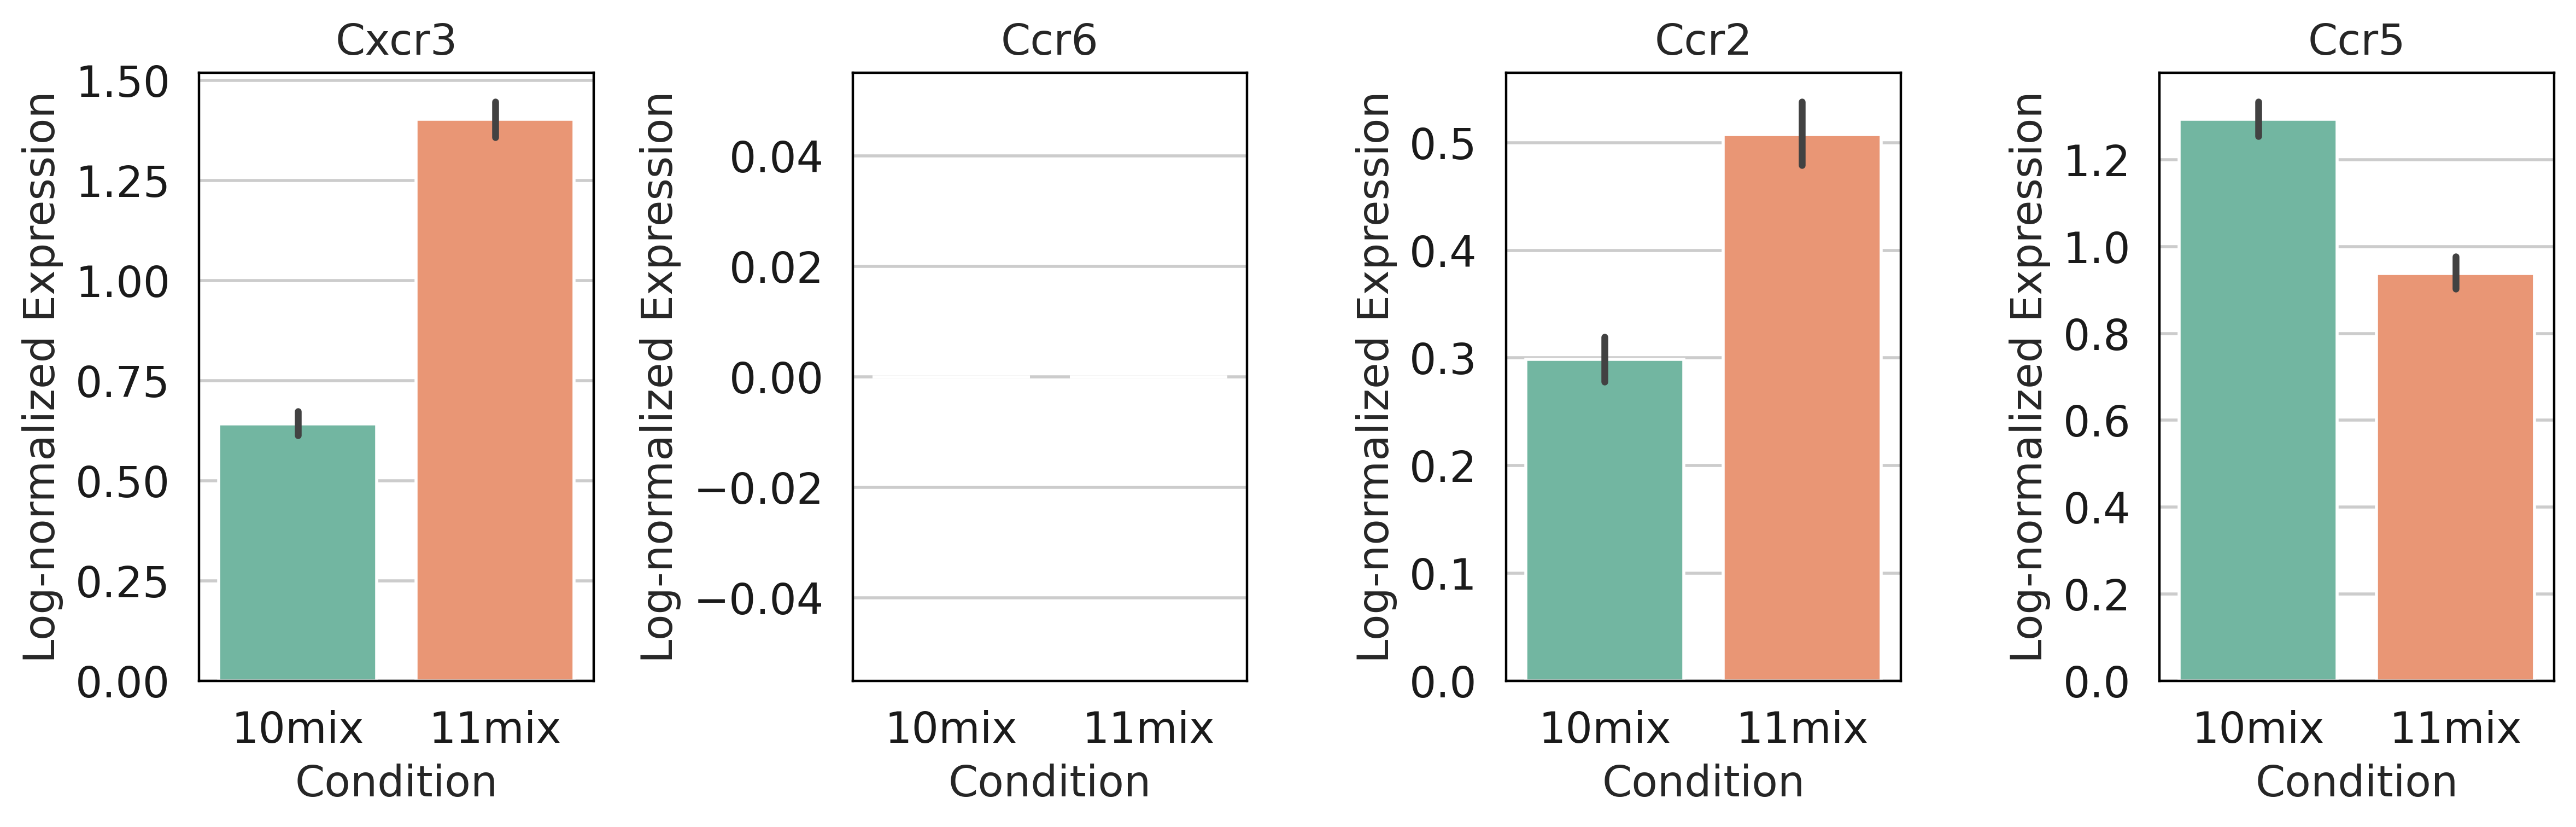

In [14]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Ensure the metadata contains a column with condition labels
condition_col = "condition"  # Adjust if necessary
cell_type_col = "cell_type"  # Adjust if necessary

# Define **mouse** homologs of receptors
mouse_genes = ["Cxcr3", "Ccr6","Ccr2","Ccr5"]  # Mouse gene symbols

# Map gene symbols to Ensembl IDs
gene_map = adata_tumor.var[adata_tumor.var["gene_name"].isin(mouse_genes)]
ensembl_ids = gene_map.index.tolist()  # Get corresponding Ensembl IDs



# Extract log-normalized expression values from "logcounts" layer
if "logcounts" in adata_tumor.layers:
    logcounts_data = adata_tumor[:, ensembl_ids].layers["logcounts"]
else:
    raise ValueError("Layer 'logcounts' not found in adata.")

# Convert expression data to a DataFrame
df = pd.DataFrame(logcounts_data, columns=gene_map["gene_name"].values, index=adata_tumor.obs.index)

# Add condition labels
df["condition"] = adata_tumor.obs[condition_col]

# Filter for 11mix and 10mix conditions
df = df[df["condition"].isin(["11mix", "10mix"])]

# Define the receptor gene columns (excluding 'condition')
receptor_columns = ["Cxcr3", "Ccr6", "Ccr2"]

# Remove rows where there are more than 2 zeros in the receptor columns
#df = df[(df[receptor_columns] != 0).sum(axis=1) > len(receptor_columns) - 1]



# Plot expression differences using violin plots
plt.figure(figsize=(12, 4))
for i, gene in enumerate(mouse_genes):
    plt.subplot(1, 4, i + 1)
    sns.barplot(x="condition", y=gene, data=df, palette="Set2")
    plt.title(f"{gene}")
    plt.xlabel("Condition")
    plt.ylabel("Log-normalized Expression")

plt.tight_layout()
plt.show()



/tmp/ipykernel_2809325/751138546.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/751138546.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/751138546.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/751138546.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

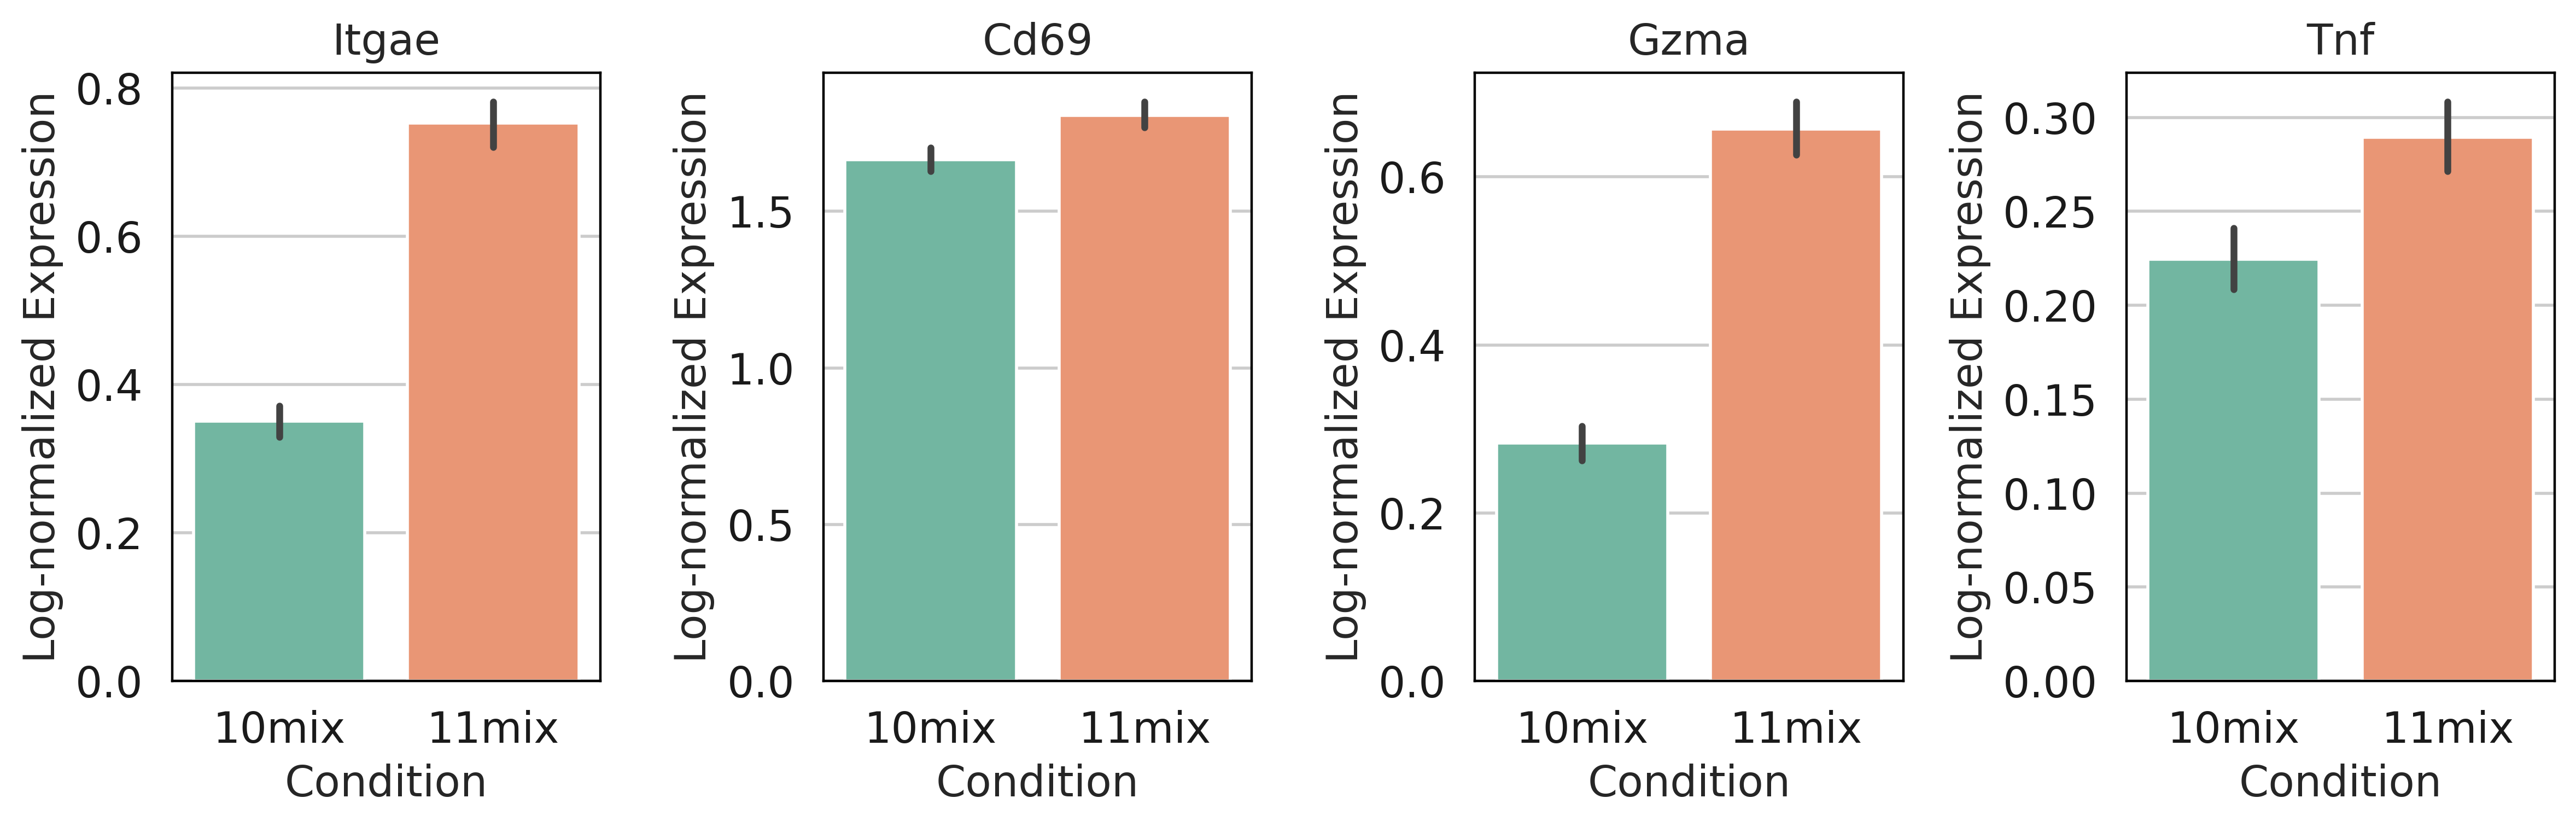

In [15]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Ensure the metadata contains a column with condition labels
condition_col = "condition"  # Adjust if necessary
cell_type_col = "cell_type"  # Adjust if necessary

# Define **mouse** homologs of receptors
mouse_genes = ["Itgae","Cd69", "Gzma","Tnf"]  # Mouse gene symbols

# Map gene symbols to Ensembl IDs
gene_map = adata.var[adata.var["gene_name"].isin(mouse_genes)]
ensembl_ids = gene_map.index.tolist()  # Get corresponding Ensembl IDs



# Extract log-normalized expression values from "logcounts" layer
if "logcounts" in adata.layers:
    logcounts_data = adata[:, ensembl_ids].layers["logcounts"]
else:
    raise ValueError("Layer 'logcounts' not found in adata.")

# Convert expression data to a DataFrame
df = pd.DataFrame(logcounts_data, columns=gene_map["gene_name"].values, index=adata.obs.index)

# Add condition labels
df["condition"] = adata.obs[condition_col]

# Filter for 11mix and 10mix conditions
df = df[df["condition"].isin(["11mix", "10mix"])]

# Plot expression differences using violin plots
plt.figure(figsize=(12, 4))
for i, gene in enumerate(mouse_genes):
    plt.subplot(1, 4, i + 1)
    sns.barplot(x="condition", y=gene, data=df, palette="Set2")
    plt.title(f"{gene}")
    plt.xlabel("Condition")
    plt.ylabel("Log-normalized Expression")

plt.tight_layout()
plt.show()



/tmp/ipykernel_2809325/2159913468.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/2159913468.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/2159913468.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/2159913468.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

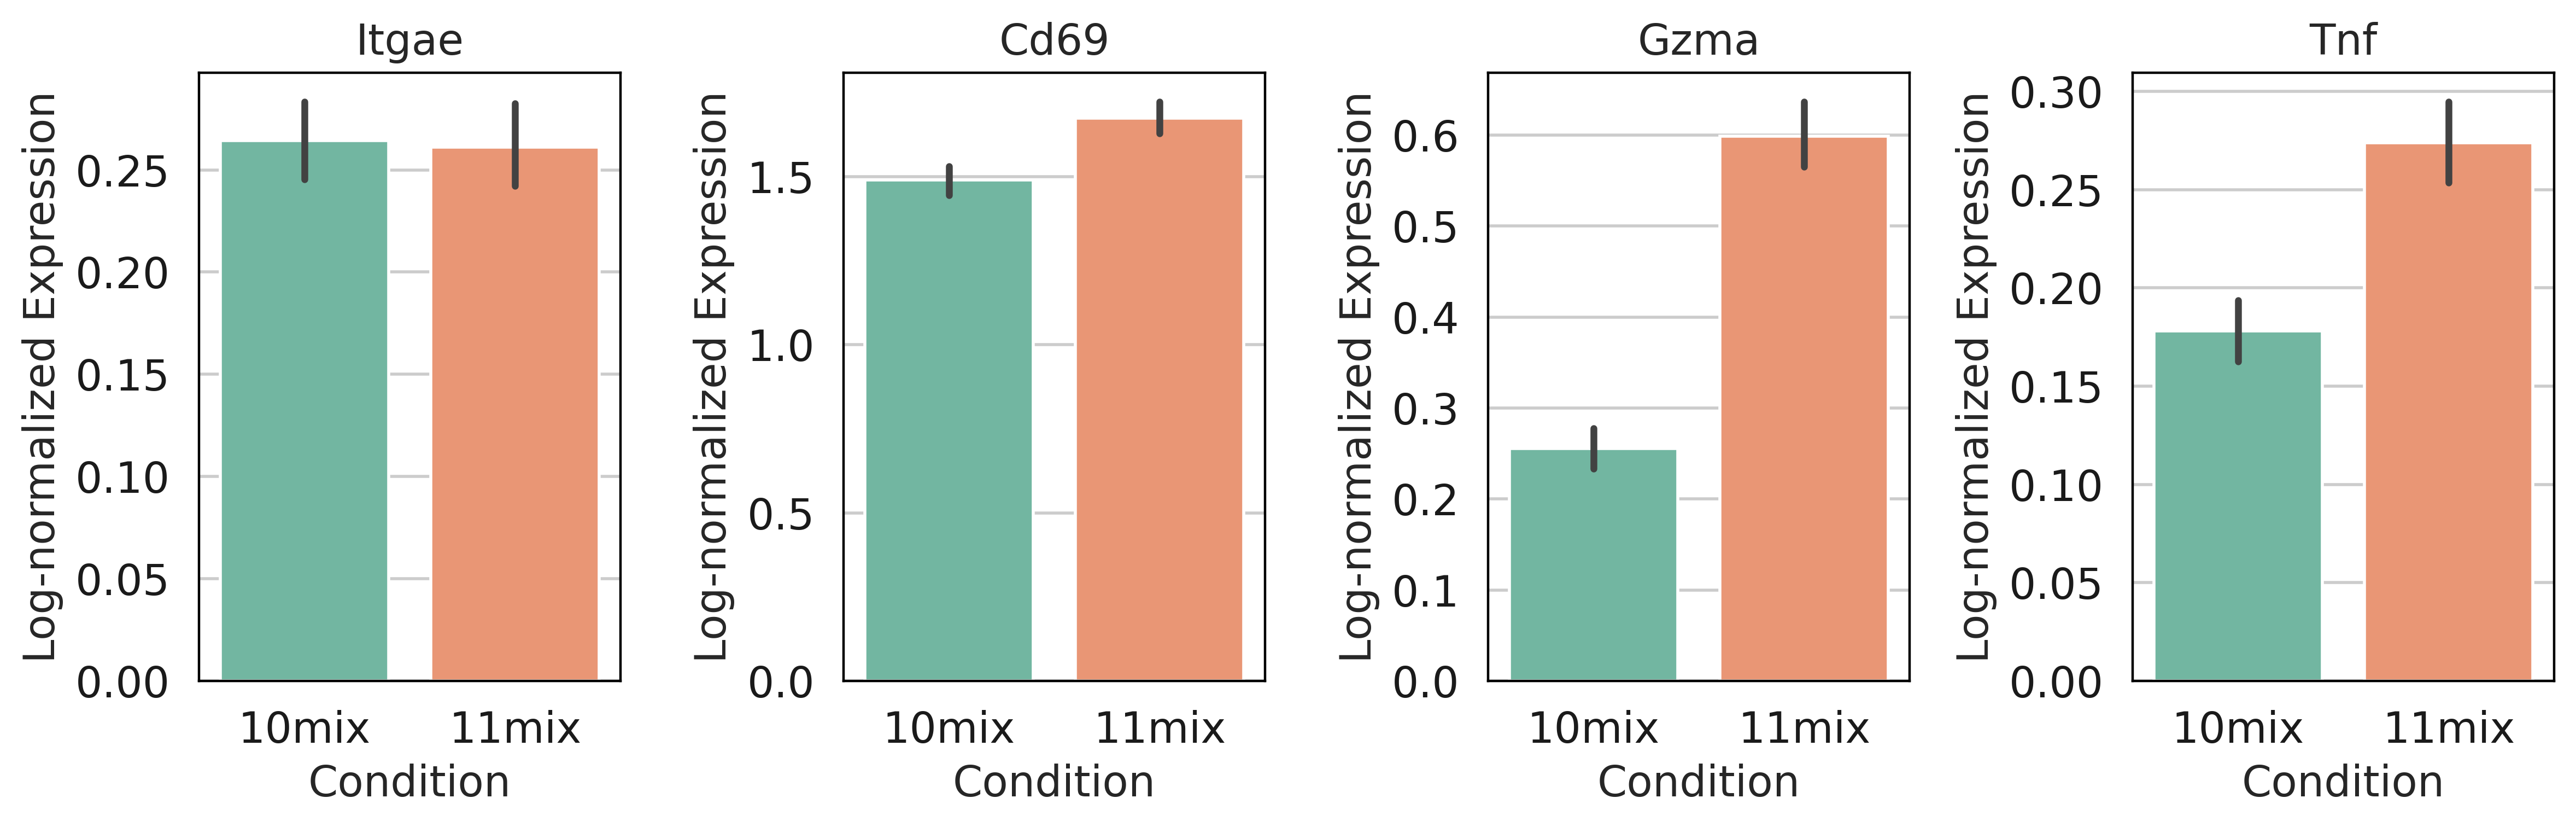

In [16]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Ensure the metadata contains a column with condition labels
condition_col = "condition"  # Adjust if necessary
cell_type_col = "cell_type"  # Adjust if necessary

# Define **mouse** homologs of receptors
mouse_genes = ["Itgae","Cd69", "Gzma","Tnf"]  # Mouse gene symbols

# Map gene symbols to Ensembl IDs
gene_map = adata_tumor.var[adata_tumor.var["gene_name"].isin(mouse_genes)]
ensembl_ids = gene_map.index.tolist()  # Get corresponding Ensembl IDs



# Extract log-normalized expression values from "logcounts" layer
if "logcounts" in adata.layers:
    logcounts_data = adata_tumor[:, ensembl_ids].layers["logcounts"]
else:
    raise ValueError("Layer 'logcounts' not found in adata.")

# Convert expression data to a DataFrame
df = pd.DataFrame(logcounts_data, columns=gene_map["gene_name"].values, index=adata_tumor.obs.index)

# Add condition labels
df["condition"] = adata_tumor.obs[condition_col]

# Filter for 11mix and 10mix conditions
df = df[df["condition"].isin(["11mix", "10mix"])]

# Plot expression differences using violin plots
plt.figure(figsize=(12, 4))
for i, gene in enumerate(mouse_genes):
    plt.subplot(1, 4, i + 1)
    sns.barplot(x="condition", y=gene, data=df, palette="Set2")
    plt.title(f"{gene}")
    plt.xlabel("Condition")
    plt.ylabel("Log-normalized Expression")

plt.tight_layout()
plt.show()



/tmp/ipykernel_2809325/3868475059.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/3868475059.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/3868475059.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="condition", y=gene, data=df, palette="Set2")
/tmp/ipykernel_2809325/3868475059.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

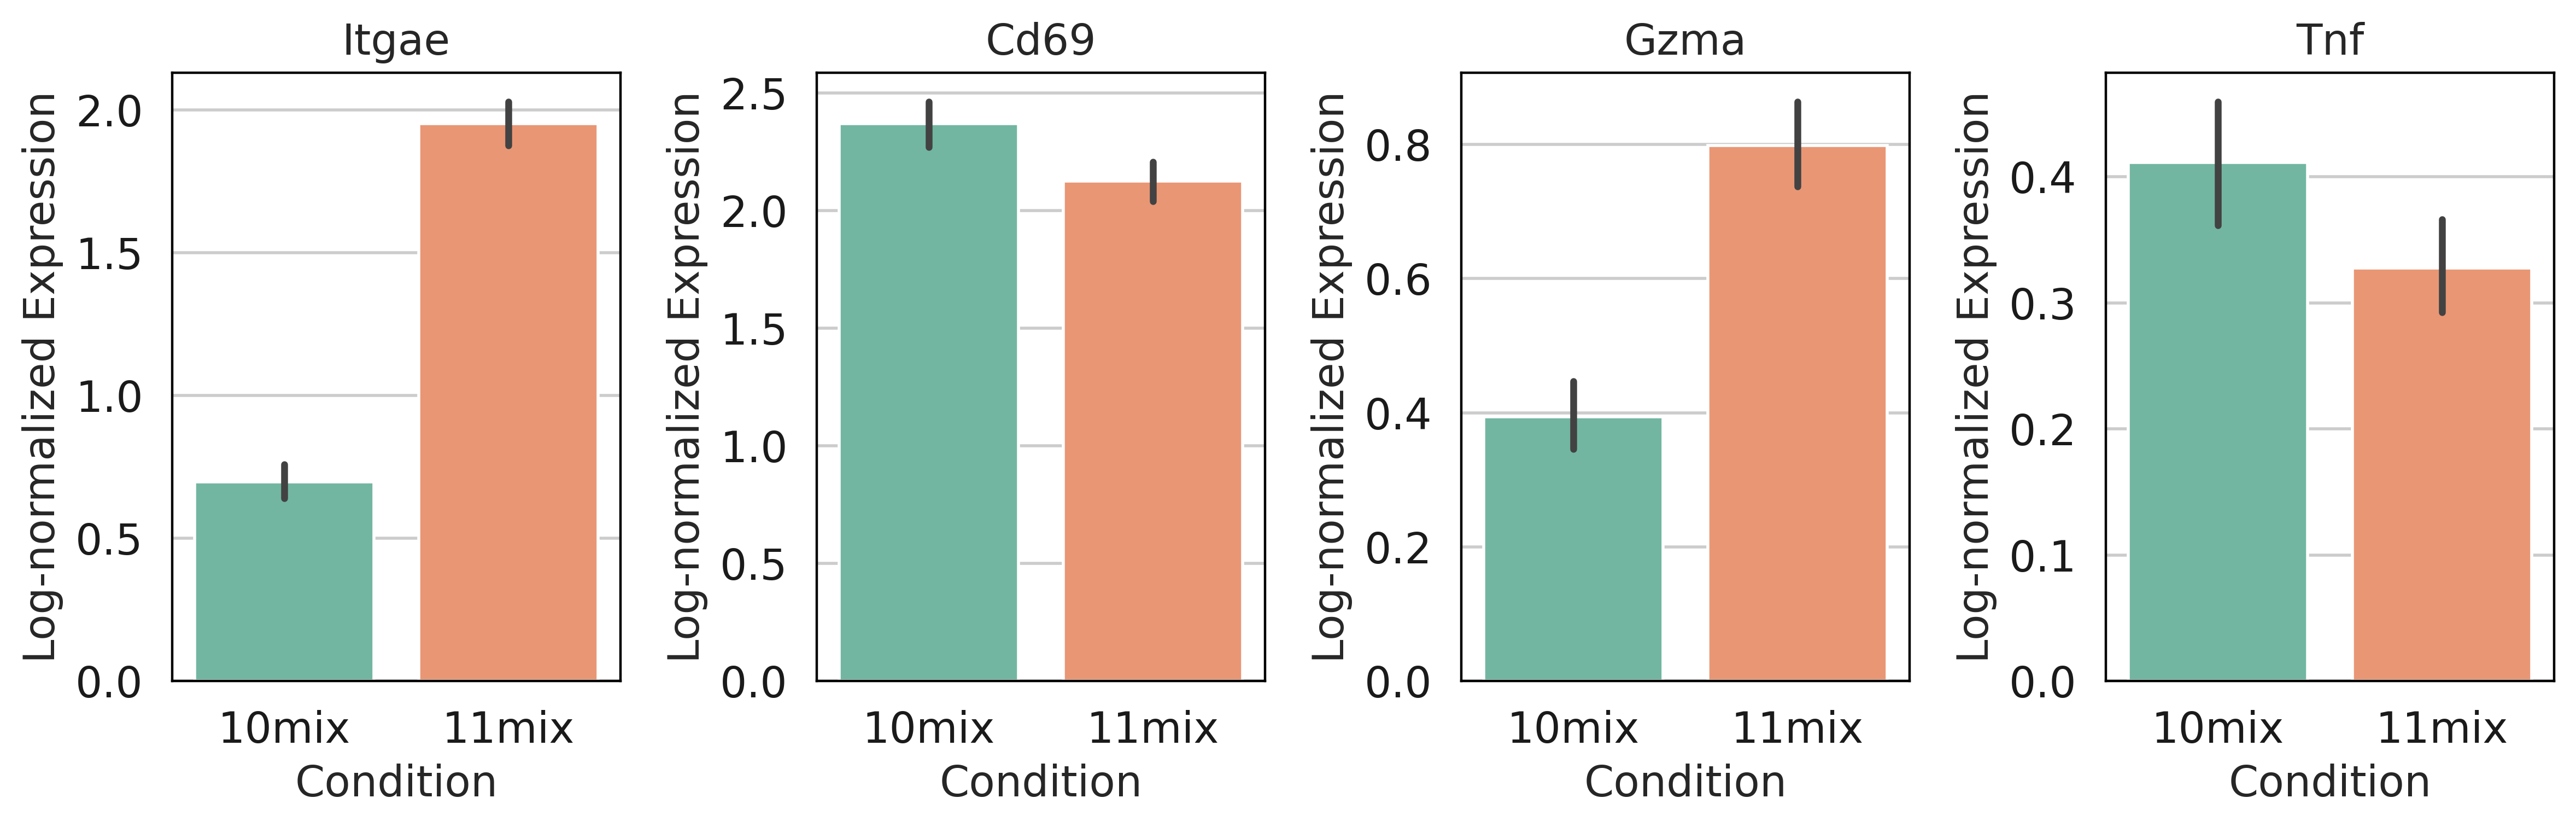

In [17]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Ensure the metadata contains a column with condition labels
condition_col = "condition"  # Adjust if necessary
cell_type_col = "cell_type"  # Adjust if necessary

# Define **mouse** homologs of receptors
mouse_genes = ["Itgae","Cd69", "Gzma","Tnf"]  # Mouse gene symbols

# Map gene symbols to Ensembl IDs
gene_map = adata_normal.var[adata_normal.var["gene_name"].isin(mouse_genes)]
ensembl_ids = gene_map.index.tolist()  # Get corresponding Ensembl IDs



# Extract log-normalized expression values from "logcounts" layer
if "logcounts" in adata.layers:
    logcounts_data = adata_normal[:, ensembl_ids].layers["logcounts"]
else:
    raise ValueError("Layer 'logcounts' not found in adata.")

# Convert expression data to a DataFrame
df = pd.DataFrame(logcounts_data, columns=gene_map["gene_name"].values, index=adata_normal.obs.index)

# Add condition labels
df["condition"] = adata_normal.obs[condition_col]

# Filter for 11mix and 10mix conditions
df = df[df["condition"].isin(["11mix", "10mix"])]

# Plot expression differences using violin plots
plt.figure(figsize=(12, 4))
for i, gene in enumerate(mouse_genes):
    plt.subplot(1, 4, i + 1)
    sns.barplot(x="condition", y=gene, data=df, palette="Set2")
    plt.title(f"{gene}")
    plt.xlabel("Condition")
    plt.ylabel("Log-normalized Expression")

plt.tight_layout()
plt.show()



In [ ]:
df